In [4]:

loan_df = pd.read_csv("Loan.txt", sep="\t")
borrower_df = pd.read_csv("Borrower.txt", sep="\t")

print("Loan shape:", loan_df.shape)
print("Borrower shape:", borrower_df.shape)
print(loan_df.columns)
print(borrower_df.columns)


Loan shape: (100000, 11)
Borrower shape: (100000, 17)
Index(['loanId', 'memberId', 'date', 'purpose', 'isJointApplication',
       'loanAmount', 'term', 'interestRate', 'monthlyPayment', 'grade',
       'loanStatus'],
      dtype='object')
Index(['memberId', 'residentialState', 'yearsEmployment', 'homeOwnership',
       'annualIncome', 'incomeVerified', 'dtiRatio', 'lengthCreditHistory',
       'numTotalCreditLines', 'numOpenCreditLines', 'numOpenCreditLines1Year',
       'revolvingBalance', 'revolvingUtilizationRate', 'numDerogatoryRec',
       'numDelinquency2Years', 'numChargeoff1year', 'numInquiries6Mon'],
      dtype='object')


In [6]:
merged_df = pd.merge(loan_df, borrower_df, on="memberId", how="inner")
print("Merged shape:", merged_df.shape)
print(merged_df.head())

Merged shape: (100000, 27)
    loanId  memberId        date            purpose  isJointApplication  \
0  1888978   2305095  12/10/2014  debtconsolidation                 0.0   
1  1299695   2610493   9/15/2014  debtconsolidation                 0.0   
2  1875016   2491679   9/11/2014  debtconsolidation                 0.0   
3  1440478   2092798   4/22/2016    homeimprovement                 0.0   
4  1124634   2633077    2/3/2016  debtconsolidation                 0.0   

   loanAmount       term  interestRate  monthlyPayment grade  ...  \
0     25190.0  60 months          6.25             490    E3  ...   
1     21189.0  60 months         10.49             455    B3  ...   
2     29908.0  60 months          9.11             622    B2  ...   
3     13053.0  48 months         11.89             343    B3  ...   
4     24613.0  60 months         15.13             587    A3  ...   

  lengthCreditHistory numTotalCreditLines numOpenCreditLines  \
0                   6                  11  

In [16]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

loan_df = pd.read_csv("Loan.txt", sep="\t")
borrower_df = pd.read_csv("Borrower.txt", sep="\t")

print("Loan shape:", loan_df.shape)
print("Borrower shape:", borrower_df.shape)
print(loan_df.columns)
print(borrower_df.columns)


merged_df = pd.merge(loan_df, borrower_df, on="memberId", how="inner")
print("Merged shape:", merged_df.shape)
print(merged_df.head())

merged_df['Target'] = merged_df['loanStatus'].apply(lambda x: 1 if x in ['Charged Off', 'Default'] else 0)
merged_df.drop('loanStatus', axis=1, inplace=True)
print(merged_df['Target'].value_counts())


merged_df['term'].fillna(merged_df['term'].mode()[0], inplace=True)
merged_df['term'] = merged_df['term'].str.replace(' months','').astype(int)

merged_df.fillna(merged_df.median(numeric_only=True), inplace=True)
merged_df.fillna('Unknown', inplace=True)

cat_cols = merged_df.select_dtypes(include='object').columns
for col in cat_cols:
    le = LabelEncoder()
    merged_df[col] = le.fit_transform(merged_df[col])

num_cols = merged_df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('Target')
scaler = StandardScaler()
merged_df[num_cols] = scaler.fit_transform(merged_df[num_cols])


X = merged_df.drop(['Target','loanId','memberId','date'], axis=1)
y = merged_df['Target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("After SMOTE, class counts:", pd.Series(y_train_res).value_counts())

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, solver='lbfgs'),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Gradient Boosting": GradientBoostingClassifier(),
    "LightGBM": lgb.LGBMClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Naive Bayes": GaussianNB()
}


def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_prob_test = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    metrics = {
        "Train Accuracy": accuracy_score(y_train, y_pred_train),
        "Test Accuracy": accuracy_score(y_test, y_pred_test),
        "Precision (macro)": precision_score(y_test, y_pred_test, average='macro'),
        "Recall (macro)": recall_score(y_test, y_pred_test, average='macro'),
        "F1-score (macro)": f1_score(y_test, y_pred_test, average='macro'),
        "AUC": roc_auc_score(y_test, y_prob_test) if y_prob_test is not None else None
    }
    return metrics


results = []
for name, model in models.items():
    metrics = evaluate_model(model, X_train_res, y_train_res, X_test, y_test)
    results.append([name] + list(metrics.values()))

results_df = pd.DataFrame(results, columns=[
    "Model","Train Accuracy","Test Accuracy","Precision (macro)",
    "Recall (macro)","F1-score (macro)","AUC"
])
print(results_df)

# Save to Excel
results_df.to_excel("CreditPath_Model_comparison.xlsx", index=False)


Loan shape: (100000, 11)
Borrower shape: (100000, 17)
Index(['loanId', 'memberId', 'date', 'purpose', 'isJointApplication',
       'loanAmount', 'term', 'interestRate', 'monthlyPayment', 'grade',
       'loanStatus'],
      dtype='object')
Index(['memberId', 'residentialState', 'yearsEmployment', 'homeOwnership',
       'annualIncome', 'incomeVerified', 'dtiRatio', 'lengthCreditHistory',
       'numTotalCreditLines', 'numOpenCreditLines', 'numOpenCreditLines1Year',
       'revolvingBalance', 'revolvingUtilizationRate', 'numDerogatoryRec',
       'numDelinquency2Years', 'numChargeoff1year', 'numInquiries6Mon'],
      dtype='object')
Merged shape: (100000, 27)
    loanId  memberId        date            purpose  isJointApplication  \
0  1888978   2305095  12/10/2014  debtconsolidation                 0.0   
1  1299695   2610493   9/15/2014  debtconsolidation                 0.0   
2  1875016   2491679   9/11/2014  debtconsolidation                 0.0   
3  1440478   2092798   4/22/2016 

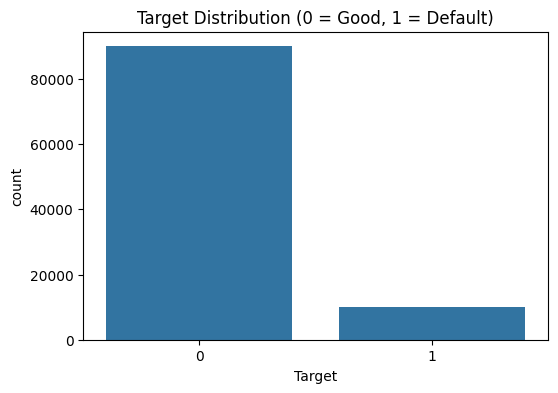

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=merged_df)
plt.title('Target Distribution (0 = Good, 1 = Default)')
plt.show()


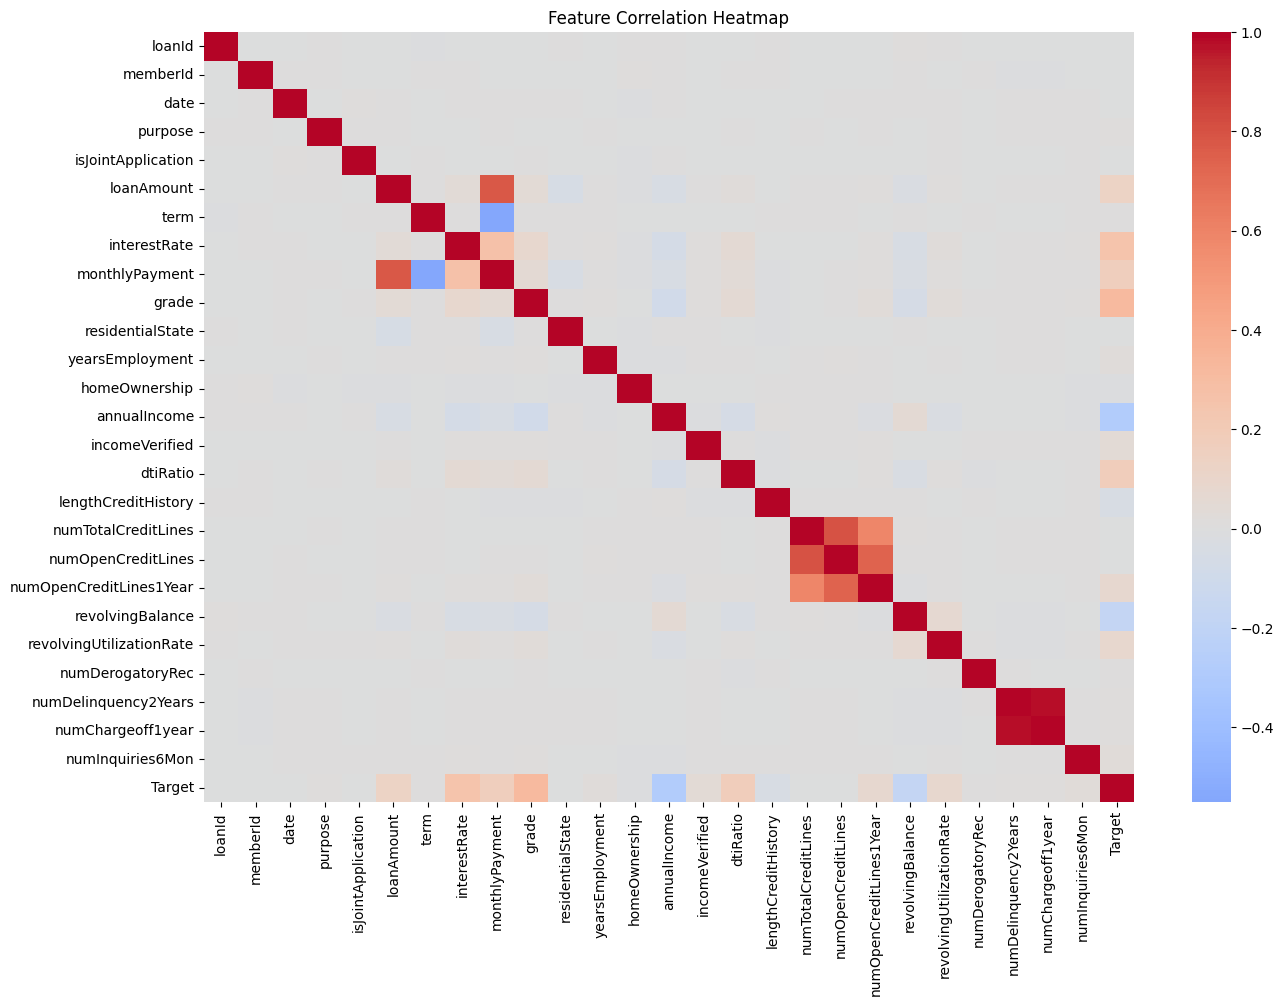

In [19]:
plt.figure(figsize=(15,10))
sns.heatmap(merged_df.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()


[LightGBM] [Info] Number of positive: 71997, number of negative: 71997
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028992 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5614
[LightGBM] [Info] Number of data points in the train set: 143994, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


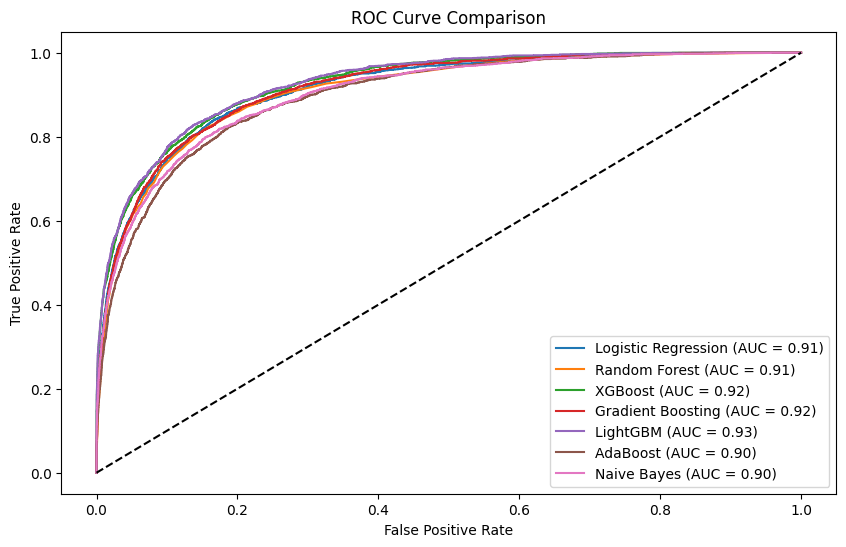

In [20]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10,6))
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


[LightGBM] [Info] Number of positive: 71997, number of negative: 71997
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018322 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5614
[LightGBM] [Info] Number of data points in the train set: 143994, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


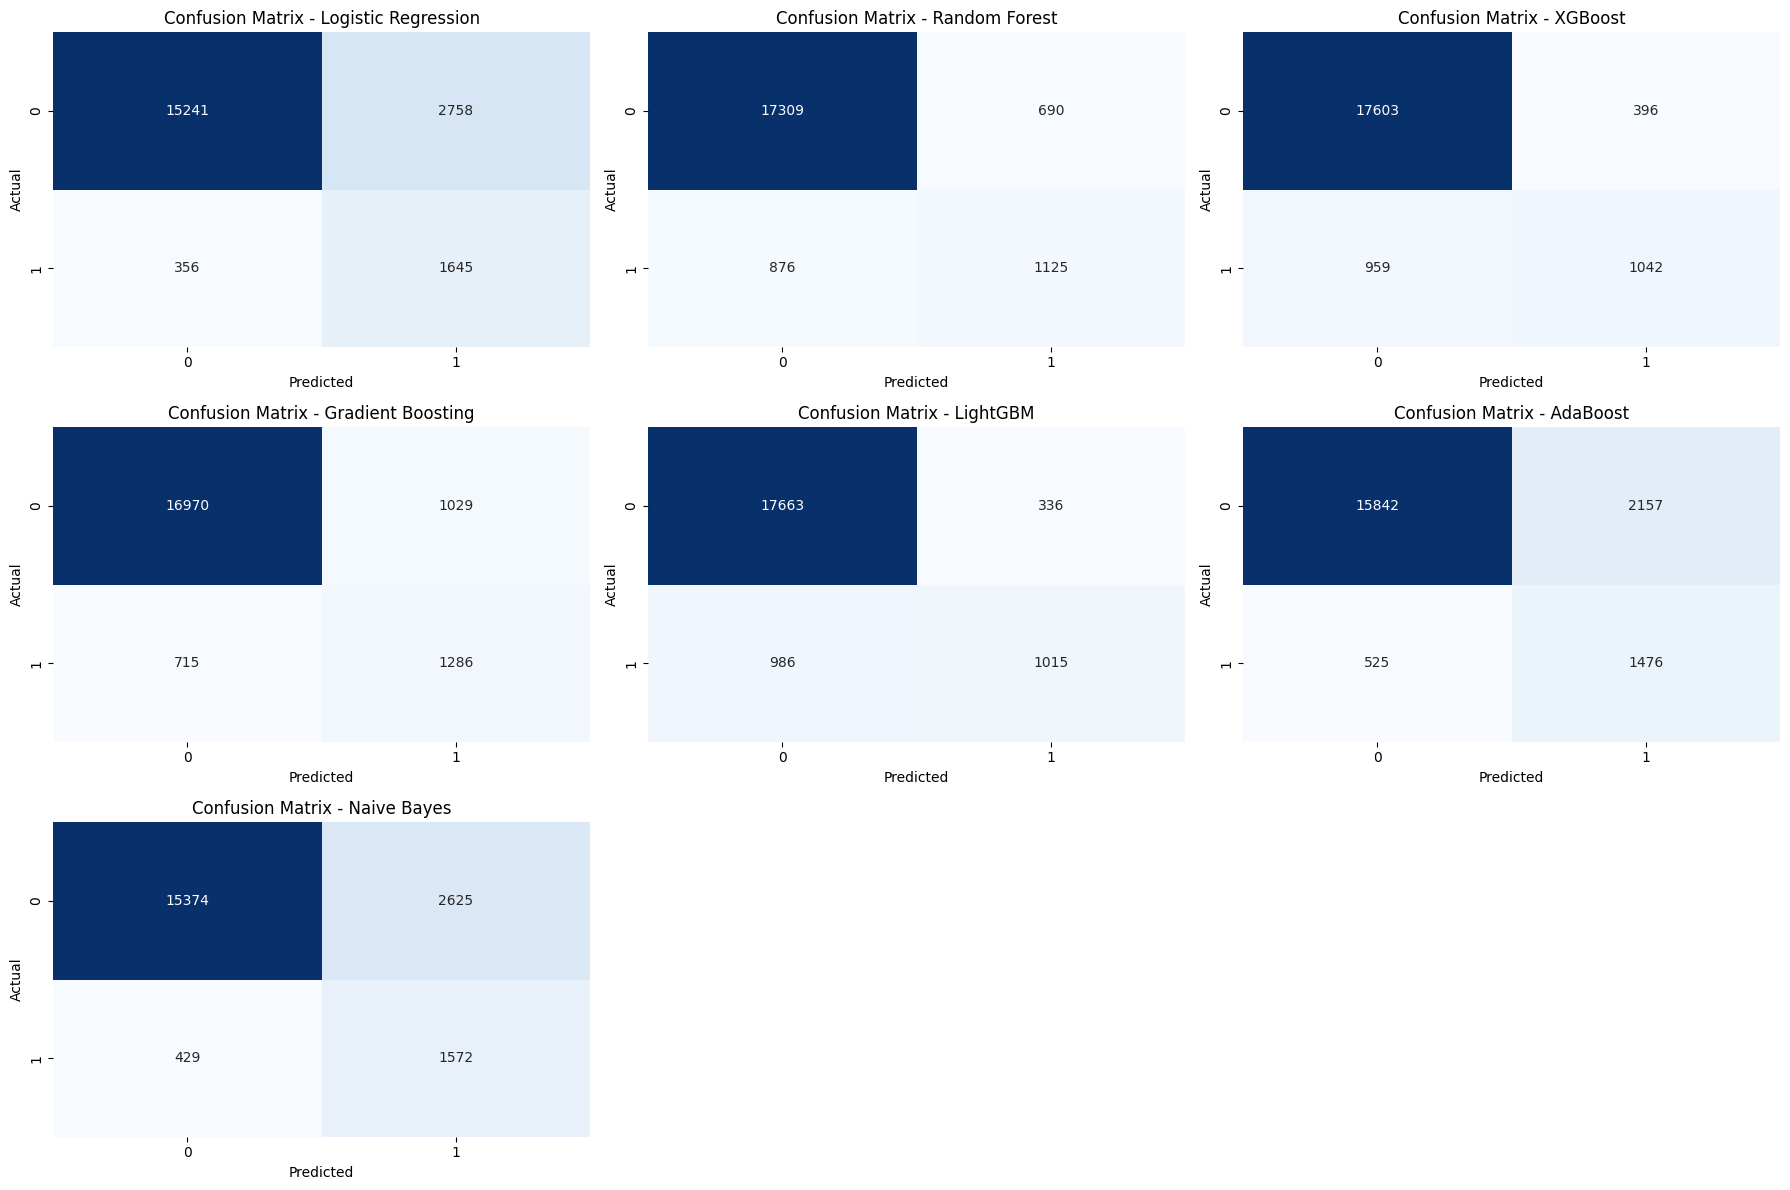

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))

for i, (name, model) in enumerate(models.items(), 1):
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(3, 3, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()
